<a href="https://colab.research.google.com/github/Kubojah-Dan/kuboja-codeboosters-2026/blob/main/DAY9/Text_to_SQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install groq -q

print("Libraties installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 3.7 MB/s eta 0:00:00
Libraties installed successfully


In [3]:
import sqlite3
import pandas as pd
import os
from groq import Groq
import re
print("All libraries imported successfully")

All libraries imported successfully


In [4]:
os.environ["GROQ_API_KEY"] = "*****************************************"

MODEL = "llama-3.1-8b-instant"

print("Groq client initialized successfully")
print(f"Using Groq model: {MODEL}")

Groq client initialized successfully
Using Groq model: llama-3.1-8b-instant


In [8]:
df = pd.read_csv("student_performance.csv")

print(df.describe())

print(df.head())

        student_id        age  semester  math_score  science_score  \
count    30.000000  30.000000      30.0   30.000000      30.000000   
mean   1015.500000  19.733333       2.0   76.066667      77.833333   
std       8.803408   0.739680       0.0   11.467896       8.554423   
min    1001.000000  19.000000       2.0   56.000000      61.000000   
25%    1008.250000  19.000000       2.0   67.250000      71.250000   
50%    1015.500000  20.000000       2.0   75.500000      78.000000   
75%    1022.750000  20.000000       2.0   85.750000      83.750000   
max    1030.000000  21.000000       2.0   95.000000      93.000000   

       english_score  programming_score  attendance_percentage  admission_year  
count      30.000000          30.000000              30.000000            30.0  
mean       74.166667          67.600000              84.500000          2023.0  
std        10.003735          21.041175               9.379913             0.0  
min        55.000000          38.000000      

In [10]:
conn = sqlite3.connect("college.db")

df.to_sql("students", conn, if_exists="replace", index=False)

print('Database created: college.db')
print("Table 'student' created with 30 student records")

test_df = pd.read_sql_query("SELECT COUNT(*) as total_rows FROM students", conn)

print(f"\nVerification: {test_df['total_rows'][0]} rows in database")

Database created: college.db
Table 'student' created with 30 student records

Verification: 30 rows in database


In [12]:
def get_schema(conn, table_name="students"):
  """
  this is a discrebtion for you
  """
  cursor = conn.cursor()
  cursor.execute(f"PRAGMA table_info({table_name})")
  columns = cursor.fetchall()

  schema_lines = [f"Table: {table_name}"]
  schema_lines.append("Columns:")

  for col in columns:
    schema_lines.append(f"  - {col[1]} ({col[2]})")

  cursor.execute(f"SELECT * FROM {table_name} LIMIT 3")
  sample_rows = cursor.fetchall()

  schema_lines.append("\nSample Rows:")
  for row in sample_rows:
    schema_lines.append(f"  - {row}")

  return "\n".join(schema_lines)

print(get_schema(conn))

Table: students
Columns:
  - student_id (INTEGER)
  - name (TEXT)
  - age (INTEGER)
  - gender (TEXT)
  - department (TEXT)
  - semester (INTEGER)
  - math_score (INTEGER)
  - science_score (INTEGER)
  - english_score (INTEGER)
  - programming_score (INTEGER)
  - attendance_percentage (INTEGER)
  - city (TEXT)
  - admission_year (INTEGER)

Sample Rows:
  - (1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023)
  - (1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023)
  - (1003, 'Rohit Verma', 19, 'Male', 'Electronics', 2, 65, 74, 61, 55, 78, 'Delhi', 2023)


In [15]:
# Writing the SQL Generation Function (SQL from a natural language question)

def generate_sql(user_question, schema_text, client, model):
  system_prompt = f"""You are an expert SQL assistant.
  You are connected to a SQLite database with the following structure;

  {schema_text}

  Rules you must follow:
  1. Generate ONLY a valid SQLite SQL query.
  2. Do not include any explanation or text - only the SQL query.
  3. Do not use markdown code blocks. Return the raw SQL only.
  4. The table name is: students
  5. Only use column names that exist in the schema above.
  6. Use single quotes for string values in WHERE clauses (example: WHERE subject = 'Programming').
  7. If the user asks for top N, use ORDER BY marks DESC LIMIT N.
  """

  response = client.chat.completions.create(
      model=model,
      messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_question}
      ],
      temperature=0.0
  )
  sql_query = response.choices[0].message.content.strip()

  return sql_query


question = "Show me all female students"
print(f"Question: {question}")
print("\nGenerating SQL......")

client = Groq(api_key=os.environ.get("GROQ_API_KEY"))
sql = generate_sql(question, get_schema(conn), client, MODEL)
print(f"SQL: {sql}")

Question: Show me all female students

Generating SQL......
SQL: SELECT * FROM students WHERE gender = 'Female'


In [16]:
def execute_sql(sql_query, conn):

  clean_sql = sql_query.strip()
  clean_sql = re.sub(r'\s*```', '', clean_sql)
  clean_sql = clean_sql.strip()

  try:
    result_df = pd.read_sql_query(clean_sql, conn)

    return result_df, None
  except Exception as e:
    return None, str(e)

print(f"Executing SQL: {sql}")
result, error = execute_sql(sql, conn)

if error:
  print(f"Error: {error}")
else:
  print(f"\nQuery returned {len(result)} rows:")
  print(result)

Executing SQL: SELECT * FROM students WHERE gender = 'Female'

Query returned 15 rows:
    student_id            name  age  gender        department  semester  \
0         1002     Priya Patel   20  Female  Computer Science         2   
1         1004     Sneha Reddy   20  Female        Mechanical         2   
2         1006     Meera Joshi   20  Female       Electronics         2   
3         1008     Divya Singh   19  Female  Computer Science         2   
4         1010      Ananya Das   19  Female  Computer Science         2   
5         1012     Pooja Gupta   19  Female             Civil         2   
6         1014   Kavya Nambiar   20  Female        Mechanical         2   
7         1016    Ritu Agarwal   20  Female       Electronics         2   
8         1018  Swati Kulkarni   19  Female  Computer Science         2   
9         1020    Nisha Kapoor   19  Female  Computer Science         2   
10        1022     Tanvi Mehta   19  Female  Computer Science         2   
11        102

In [22]:
# THe Complete Text-to-SQL Agent function

def text_to_sql(user_question, conn, client, model, verbose=True):

  print("=" * 60)
  print(f"User Question: {user_question}")
  print("=" * 60)

  if verbose:
    print("\n[STEP 1] Reading database schema....")
    short_text = get_schema(conn)

  if verbose:

    print("Schema loaded successfully")

  generated_sql = generate_sql(user_question, get_schema(conn), client, model)

  if verbose:
    print(f"Generated SQL: \n {generated_sql}")
  if verbose:
    print("\n[STEP 3] Executing SQL on the database....")
  result_df, error = execute_sql(generated_sql, conn)

  if error:
    print(f"SQL Execution Error: {error}")
    return None, generated_sql

  if verbose:
    print(f"\n[STEP 4] Query returned {len(result_df)} row(s)")
    print("\nRESULTS:")
    print("-" * 40)
    print(result_df.to_string(index=False))
  print("=" * 60)

  return result_df, generated_sql

result, sql_used = text_to_sql("Show top 5 students in Programming", conn, client, MODEL, verbose=True)

User Question: Show top 5 students in Programming

[STEP 1] Reading database schema....
Schema loaded successfully
Generated SQL: 
 SELECT name FROM students ORDER BY programming_score DESC LIMIT 5

[STEP 3] Executing SQL on the database....

[STEP 4] Query returned 5 row(s)

RESULTS:
----------------------------------------
          name
    Ananya Das
   Tanvi Mehta
    Arjun Nair
Akanksha Yadav
   Divya Singh


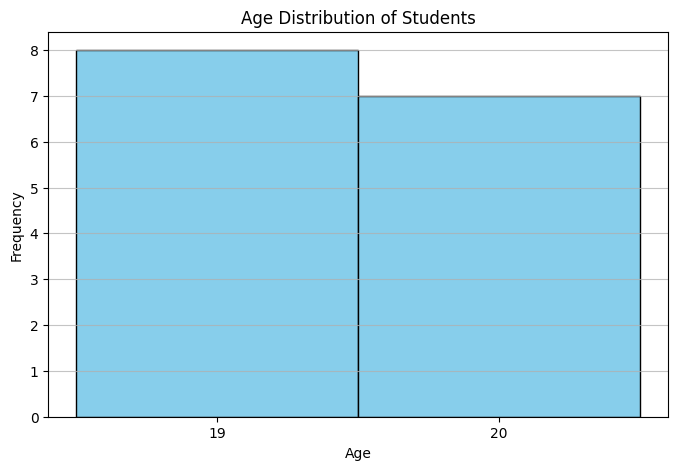

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(result['age'], bins=range(min(result['age']), max(result['age']) + 2), color='skyblue', edgecolor='black', align='left')
plt.title('Age Distribution of Students')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.xticks(range(min(result['age']), max(result['age']) + 1))
plt.grid(axis='y', alpha=0.75)
plt.show()

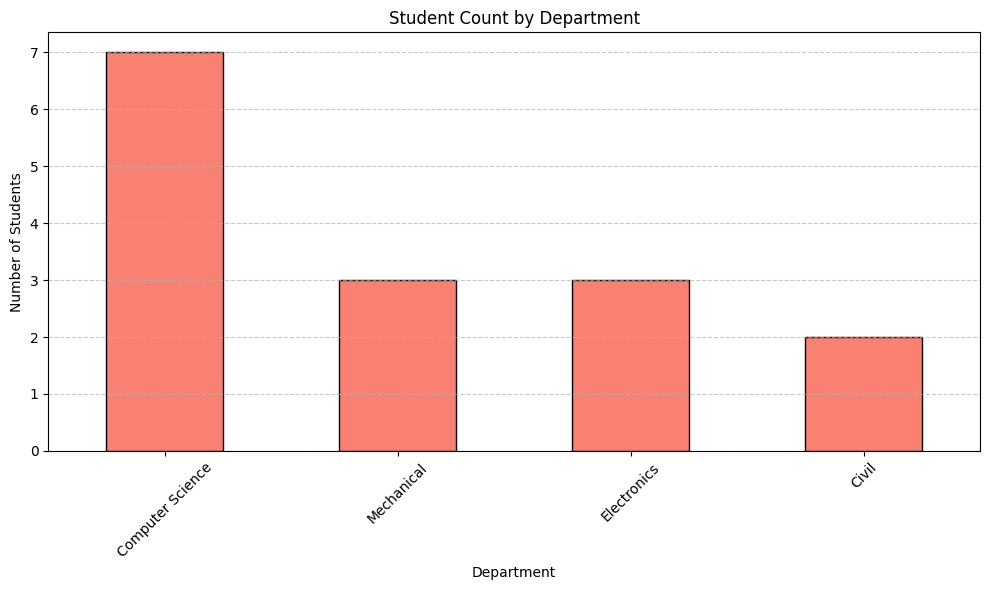

In [21]:
department_counts = result['department'].value_counts()

plt.figure(figsize=(10, 6))
department_counts.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Student Count by Department')
plt.xlabel('Department')
plt.ylabel('Number of Students')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Twilio** **WhatsApp** **SandBox** **-** **Send** **Messages**

In [23]:
!pip install twilio -q
print("Twilio library installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 22.0 MB/s eta 0:00:00
Twilio library installed successfully


In [26]:
import os
from getpass import getpass
from twilio.rest import Client

# ---------Twilio Credentials -----------
TW_SID = os.environ.get('TWILIO_SID')
TW_TOKEN = os.environ.get('TWILIO_TOKEN')

if not TW_SID or not TW_TOKEN:
  print("Enter your Twilio Account SID and Auth Token:")
  TW_SID = getpass('Enter Twilio Account SID: ')
  TW_TOKEN = getpass('Enter Twilio Account Token: ')
  os.environ['TWILIO_SID'] = TW_SID
  os.environ['TWILIO_TOKEN'] = TW_TOKEN

FROM = "whatsapp:+14155238886"
raw_to = input("Enter your whatsapp number (e.g. +91XXXXXXXXXX): ")

TO = raw_to if raw_to.startswith('whatsapp:') else f'whatsapp:{raw_to}'
MESSAGE_BODY = input("Enter the message you want to send: ")

twilio_client = Client(TW_SID, TW_TOKEN)

try:
    message = twilio_client.messages.create(
        from_=FROM,
        body=MESSAGE_BODY,
        to=TO
    )
    print(f"Twilio client initialized successfully")
    print(f"Message sent! SID: {message.sid}")
except Exception as e:
    print(f"Error sending message: {e}")

Enter your whatsapp number (e.g. +91XXXXXXXXXX): +918452932842
Enter the message you want to send: Whatsapp testing message!
Error sending message: HTTP 400 error: Unable to create record: Twilio could not find a Channel with the specified From address


# **LeetCode** **Solver** **Agent** **=>** **Twilio** + **Groq** **API**

In [27]:
import os
from getpass import getpass
from twilio.rest import Client
from groq import Groq

# 1. Setup Credentials
print("--- API Configuration ---")
groq_key = getpass("Enter Groq API Key: ")
tw_sid = getpass("Enter Twilio Account SID: ")
tw_token = getpass("Enter Twilio Auth Token: ")

os.environ["GROQ_API_KEY"] = groq_key
client_groq = Groq(api_key=groq_key)
twilio_client = Client(tw_sid, tw_token)

# 2. Input Problem Details
problem_title = input("\nEnter the LeetCode Problem Title: ")
whatsapp_number = input("Enter your WhatsApp number (e.g., +91XXXXXXXXXX): ")
whatsapp_to = whatsapp_number if whatsapp_number.startswith('whatsapp:') else f'whatsapp:{whatsapp_number}'

# 3. Generate Solution using Groq
print(f"\nGenerating solution for: {problem_title}...")

system_msg = "You are a competitive programming expert. Provide only the Python solution code for the given LeetCode problem. Include brief comments. No conversational text."
prompt = f"Solve the LeetCode problem: {problem_title}. Provide a clean, optimized Python solution."

completion = client_groq.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[{"role": "system", "content": system_msg}, {"role": "user", "content": prompt}],
    temperature=0.1
)

solution_code = completion.choices[0].message.content
print("Solution generated successfully.")

# 4. Send via Twilio
print("Sending to WhatsApp...")
try:
    msg_body = f"*LeetCode Solution: {problem_title}*\n\n{solution_code}"
    message = twilio_client.messages.create(
        from_="whatsapp:+14155238886",
        body=msg_body,
        to=whatsapp_to
    )
    print(f"Success! Message SID: {message.sid}")
except Exception as e:
    print(f"Error sending WhatsApp message: {e}")
    print("Note: Make sure you have joined the Twilio Sandbox by sending 'join [keyword]' to +1 415 523 8886")

--- API Configuration ---
Enter Groq API Key: ··········
Enter Twilio Account SID: ··········
Enter Twilio Auth Token: ··········

Enter the LeetCode Problem Title: Two Sum
Enter your WhatsApp number (e.g., +91XXXXXXXXXX): +918452932842

Generating solution for: Two Sum...
Solution generated successfully.
Sending to WhatsApp...
Success! Message SID: SM107914787784ec8d2497032b1b63a5ac
